In [1]:
import torch 
import numpy as np 
import h5py
import os
from pathlib import Path
import IPython.display as ipd 
import h5py 
import pickle
import sys

sys.path.append('/om2/user/imgriff/datasets/spatial_audio_pipeline/')
from utils import util_audio

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [27]:

def remap_azim(azim):
    if azim >= 180:
        return 360 - azim
    else:
        return 0 - azim
remap_azim = np.vectorize(remap_azim)

In [69]:
## Set up paths 
path_to_outputs = Path("distractor_optimization/spatialization_gridsearch")
files = list(path_to_outputs.glob("*/*.h5"))
files

[PosixPath('distractor_optimization/spatialization_gridsearch/word_task_half_co_loc_v07/word_task_half_co_loc_v07_azim_search_seed0.h5')]

In [70]:
output_file = h5py.File(files[0],'r')

In [71]:
output_file.keys()

<KeysViewHDF5 ['azimuths', 'losses']>

In [87]:
## Get plot order from azimuths 
azimuths = output_file['azimuths'][:]
re_ordered = remap_azim(np.copy(azimuths))

new_order = np.argsort(re_ordered)
re_ordered = re_ordered[new_order]
re_ordered

array([-175, -170, -165, -160, -155, -150, -145, -140, -135, -130, -125,
       -120, -115, -110, -105, -100,  -95,  -90,  -85,  -80,  -75,  -70,
        -65,  -60,  -55,  -50,  -45,  -40,  -35,  -30,  -25,  -20,  -15,
        -10,   -5,    0,    5,   10,   15,   20,   25,   30,   35,   40,
         45,   50,   55,   60,   65,   70,   75,   80,   85,   90,   95,
        100,  105,  110,  115,  120,  125,  130,  135,  140,  145,  150,
        155,  160,  165,  170,  175,  180])

In [73]:
re_ordered

array([-175, -170, -165, -160, -155, -150, -145, -140, -135, -130, -125,
       -120, -115, -110, -105, -100,  -95,  -90,  -85,  -80,  -75,  -70,
        -65,  -60,  -55,  -50,  -45,  -40,  -35,  -30,  -25,  -20,  -15,
        -10,   -5,    0,    5,   10,   15,   20,   25,   30,   35,   40,
         45,   50,   55,   60,   65,   70,   75,   80,   85,   90,   95,
        100,  105,  110,  115,  120,  125,  130,  135,  140,  145,  150,
        155,  160,  165,  170,  175,  180])

Text(0, 0.5, 'Example')

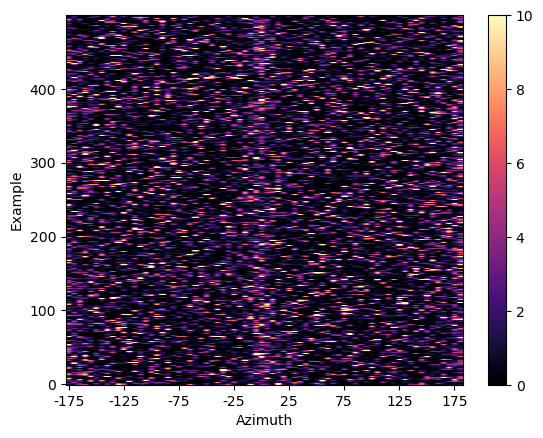

In [74]:
### Plot distribution of losses x time 
losses = output_file['losses'][:]
azimuths = output_file['azimuths'][:]

# min/max scale the rows 
# losses = (losses - losses.min(axis=1)[:,None]) / (losses.max(axis=1) - losses.min(axis=1))[:,None]
plt.imshow(losses[:,new_order], aspect='auto', origin='lower', vmax=10, cmap='magma', interpolation=None)
plt.colorbar()
plt.xlabel('Azimuth')
# rename x tick 
plt.xticks(np.arange(0, len(re_ordered), 10), re_ordered[::10])
plt.ylabel('Example')



In [75]:
best_losses = np.argmax(losses, axis=1) 

<AxesSubplot:ylabel='Probability'>

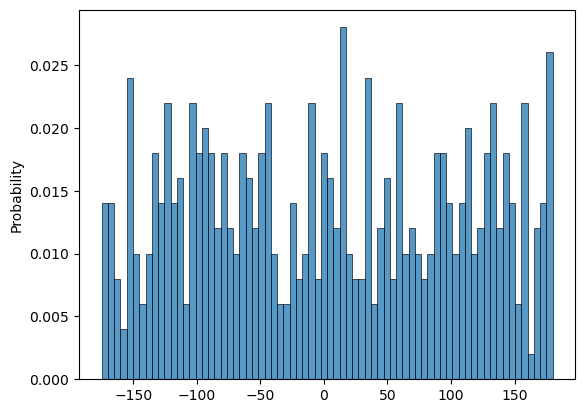

In [76]:
### Plot distribution of best_ixs 

best_azimuths = azimuths[np.argmax(losses, axis=1)]
# get hits of best_azimuths, then plot with polor ordering with 0 at middle and +/- 180 at the left and right 
best_azimuths[best_azimuths > 180] = best_azimuths[best_azimuths > 180] - 360
sns.histplot(best_azimuths, stat='probability', bins=72)

In [77]:
re_ordered

array([-175, -170, -165, -160, -155, -150, -145, -140, -135, -130, -125,
       -120, -115, -110, -105, -100,  -95,  -90,  -85,  -80,  -75,  -70,
        -65,  -60,  -55,  -50,  -45,  -40,  -35,  -30,  -25,  -20,  -15,
        -10,   -5,    0,    5,   10,   15,   20,   25,   30,   35,   40,
         45,   50,   55,   60,   65,   70,   75,   80,   85,   90,   95,
        100,  105,  110,  115,  120,  125,  130,  135,  140,  145,  150,
        155,  160,  165,  170,  175,  180])

Text(0.5, 1.0, 'Loss as function of distractor azimuth')

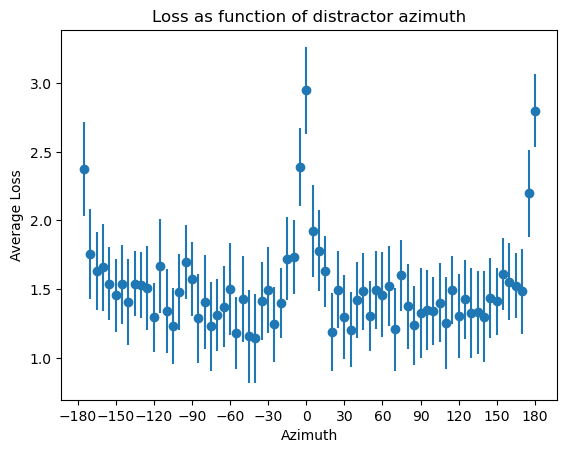

In [103]:
## get average loss per azimuth 

avg_losses = losses.mean(0)
# plt 2 sem
loss_err =  2 * np.std(losses, axis=0) / np.sqrt(losses.shape[0])

plt.errorbar(re_ordered, avg_losses[new_order], yerr=loss_err, fmt='o')
plt.xlabel('Azimuth')
plt.ylabel('Average Loss')
plt.xticks(np.arange(-180, 181, 30));
plt.title("Loss as function of distractor azimuth")


In [79]:
azimuths

array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
       130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
       195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255,
       260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320,
       325, 330, 335, 340, 345, 350, 355])

Text(0.5, 1.0, 'Loss as function of distractor azimuth (left-right folded)')

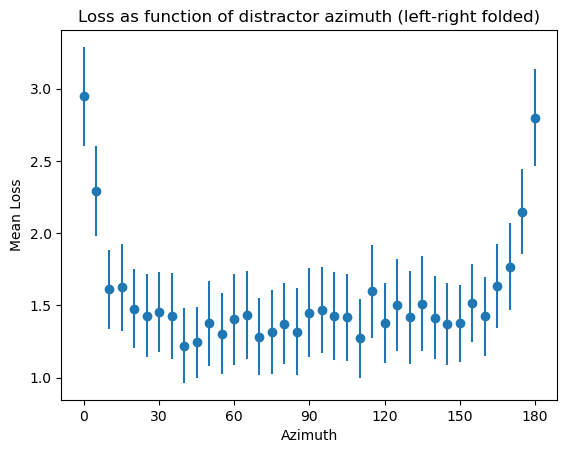

In [104]:
## Fold loss matrix over 180
folded_losses = np.zeros((losses.shape[0]*2, losses.shape[1]//2 + 1))
# manually fold left-right into same bins 
folded_losses[:losses.shape[0],:] = losses[:,0:37]
folded_losses[losses.shape[0]:,1:-1] = losses[:,37:][::-1]
folded_losses[losses.shape[0]:,0] = np.nan
folded_losses[losses.shape[0]:,-1] = np.nan
# map azimuths to 0-180
half_azimuths = output_file['azimuths'][:37]

# get average loss per azimuth
avg_losses = np.nanmean(folded_losses, axis=0)
# plt 2 sem
loss_err =  2 * np.nanstd(folded_losses, axis=0) / np.sqrt(losses.shape[0])
#plot
plt.errorbar(half_azimuths, avg_losses, yerr=loss_err, fmt='o')
plt.xlabel('Azimuth')
plt.ylabel('Mean Loss')
plt.xticks(np.arange(0,181,30));
plt.title("Loss as function of distractor azimuth (left-right folded)")

(35,)

In [1]:
h5_dataset = h5py.File("/om/user/imgriff/datasets/human_word_rec_SWC_2023/model_eval_stim.h5", 'r')
print(h5_dataset.keys())
h5_dataset.close()

NameError: name 'h5py' is not defined

In [17]:
import numpy as np 
n_first, n_mid, n_last = 3, 2, 4
global_ixs = np.zeros((n_first*n_mid*n_last))
for ix, i in enumerate(range(n_first)):
    for jx, j in enumerate(range(n_mid)):
        for kx, k in enumerate(range(n_last)):
            # print(i,j,k)
            #global ix
            global_ix = i * (n_last*n_mid) + j * n_last + k
            global_ixs[global_ix]  = global_ix
            print(global_ix) 
(1==np.diff(global_ixs)).all()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


True